In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('/content/archive (1).zip')

In [ ]:
df.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


,loan_id,no_of_dependents,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value
count,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4269.000000,4269.000000,4.269000e+03,4.269000e+03,4.269000e+03,4.269000e+03
mean,2135.000000,2.498712,5.059124e+06,1.513345e+07,10.900445,599.936051,7.472617e+06,4.973155e+06,1.512631e+07,4.976692e+06
std,1232.498479,1.695910,2.806840e+06,9.043363e+06,5.709187,172.430401,6.503637e+06,4.388966e+06,9.103754e+06,3.250185e+06
min,1.000000,0.000000,2.000000e+05,3.000000e+05,2.000000,300.000000,-1.000000e+05,0.000000e+00,3.000000e+05,0.000000e+00
25%,1068.000000,1.000000,2.700000e+06,7.700000e+06,6.000000,453.000000,2.200000e+06,1.300000e+06,7.500000e+06,2.300000e+06
50%,2135.000000,3.000000,5.100000e+06,1.450000e+07,10.000000,600.000000,5.600000e+06,3.700000e+06,1.460000e+07,4.600000e+06
75%,3202.000000,4.000000,7.500000e+06,2.150000e+07,16.000000,748.000000,1.130000e+07,7.600000e+06,2.170000e+07,7.100000e+06
max,4269.000000,5.000000,9.900000e+06,3.950000e+07,20.000000,900.000000,2.910000e+07,1.940000e+07,3.920000e+07,1.470000e+07


In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
df['loan_status'] = df['loan_status'].map({
    ' Approved': 1,
    ' Rejected': 0,
    'Approved': 1,
    'Rejected': 0
})

In [ ]:
df['education'] = df['education'].map({
    ' Graduate': 1,
    ' Not Graduate': 0,
    'Graduate': 1,
    'Not Graduate': 0
})

df['self_employed'] = df['self_employed'].map({
    ' Yes': 1,
    ' No': 0,
    'Yes': 1,
    'No': 0
})

In [ ]:
np.random.seed(42)

random_index = np.random.choice(df.index, size=int(0.1 * len(df)), replace=False)

df.loc[random_index, 'cibil_score'] = -1

In [ ]:
df['credit_history'] = df['cibil_score'].apply(lambda x: 0 if x == -1 else 1)

In [ ]:
df['total_assets'] = (
    df['residential_assets_value'] +
    df['commercial_assets_value'] +
    df['luxury_assets_value'] +
    df['bank_asset_value']
)

In [ ]:
df['loan_income_ratio'] = df['loan_amount'] / df['income_annum']

In [ ]:
df['asset_loan_ratio'] = df['total_assets'] / df['loan_amount']

In [ ]:
df = df.drop(['loan_id'], axis=1)

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
train_columns = X.columns

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)
import pickle

In [ ]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7447306791569087


In [ ]:
sample = X_test.iloc[0:1]

prob = model.predict_proba(sample)

print("Prediction:", model.predict(sample))
print("Default Probability:", prob[0][0])

Prediction: [0]
Default Probability: 0.95


In [ ]:
def predict_loan():
    user_data = get_user_input()
    processed_data = preprocess_input(user_data)

    prediction = model.predict(processed_data)
    prob = model.predict_proba(processed_data)

    default_prob = prob[0][0]
    approval_prob = prob[0][1]

    # Result
    if prediction[0] == 1:
        print("✅ Loan Approved")
    else:
        print("❌ Loan Rejected")

    print(f"Default Probability: {default_prob:.2f}")

    if default_prob < 0.3:
        print("🟢 Low Risk Customer")
    elif default_prob < 0.6:
        print("🟡 Medium Risk Customer")
    else:
        print("🔴 High Risk Customer")

    # ✅ PASTE GRAPH CODE HERE 👇
    labels = ['Default Risk', 'Approval Chance']
    values = [default_prob, approval_prob]

    plt.figure()
    plt.bar(labels, values)
    plt.title("Loan Risk Analysis")
    plt.xlabel("Category")
    plt.ylabel("Probability")
    plt.ylim(0, 1)
    plt.show()

In [ ]:
def get_user_input():
    no_of_dependents = int(input("Enter number of dependents: "))
    education = input("Education (Graduate/Not Graduate): ")
    self_employed = input("Self employed (Yes/No): ")
    income_annum = int(input("Annual Income: "))
    loan_amount = int(input("Loan Amount: "))
    loan_term = int(input("Loan Term: "))

    has_credit = input("Do you have credit history? (Yes/No): ")

    if has_credit == "Yes":
        cibil_score = int(input("Enter CIBIL Score (300-900): "))
        credit_history = 1
    else:
        cibil_score = -1
        credit_history = 0

    residential_assets = int(input("Residential Assets Value: "))
    commercial_assets = int(input("Commercial Assets Value: "))
    luxury_assets = int(input("Luxury Assets Value: "))
    bank_assets = int(input("Bank Balance: "))

    return {
        'no_of_dependents': no_of_dependents,
        'education': education,
        'self_employed': self_employed,
        'income_annum': income_annum,
        'loan_amount': loan_amount,
        'loan_term': loan_term,
        'cibil_score': cibil_score,
        'credit_history': credit_history,
        'residential_assets_value': residential_assets,
        'commercial_assets_value': commercial_assets,
        'luxury_assets_value': luxury_assets,
        'bank_asset_value': bank_assets
    }

In [ ]:
def preprocess_input(data):
    df = pd.DataFrame([data])

    # Convert categorical
    df['education'] = df['education'].map({'Graduate':1, 'Not Graduate':0})
    df['self_employed'] = df['self_employed'].map({'Yes':1, 'No':0})

    # Feature engineering
    df['total_assets'] = (
        df['residential_assets_value'] +
        df['commercial_assets_value'] +
        df['luxury_assets_value'] +
        df['bank_asset_value']
    )

    df['loan_income_ratio'] = df['loan_amount'] / df['income_annum']
    df['asset_loan_ratio'] = df['total_assets'] / df['loan_amount']

    # 🔥 VERY IMPORTANT: Match training columns
    df = df.reindex(columns=train_columns, fill_value=0)

    return df

Enter number of dependents: 2
Education (Graduate/Not Graduate): Not graduate
Self employed (Yes/No): No
Annual Income: 200000
Loan Amount: 80000
Loan Term: 12
Do you have credit history? (Yes/No): Yes
Enter CIBIL Score (300-900): 598
Residential Assets Value: 400000
Commercial Assets Value: 0
Luxury Assets Value: 0
Bank Balance: 200000
✅ Loan Approved
Default Probability: 0.32
🟡 Medium Risk Customer


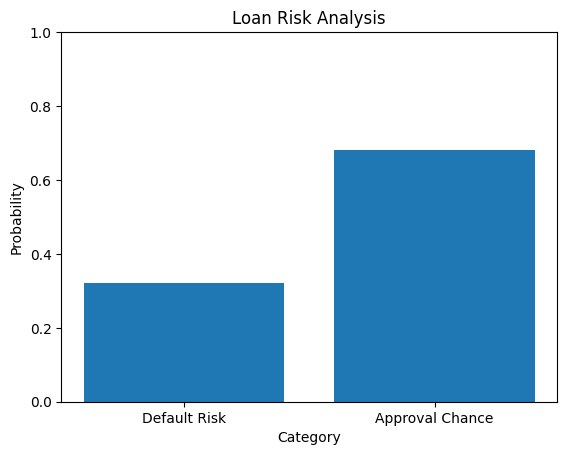

In [ ]:

predict_loan()